## 🧠 MNIST Image Classification with a Neural Network

### 📦 Objective:
Train a basic neural network to recognize handwritten digits (0–9) from grayscale images in the MNIST dataset.

---

### 🔧 Step-by-Step Breakdown

#### 🔹 Step 1: Import Libraries

In [1]:
pip install -q tensorflow matplotlib seaborn numpy scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [2]:
import warnings
warnings.filterwarnings('ignore')

In [3]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical
import matplotlib.pyplot as plt

---

#### 🔹 Step 2: Load and Preprocess Data

In [16]:
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# Normalize pixel values
x_train, x_test = x_train / 255.0, x_test / 255.0

# One-hot encode labels
y_train = to_categorical(y_train)
y_test = to_categorical(y_test)

In [18]:
y_train[0]

array([0., 0., 0., 0., 0., 1., 0., 0., 0., 0.])

---

#### 🔹 Step 3: Visualize Sample Images

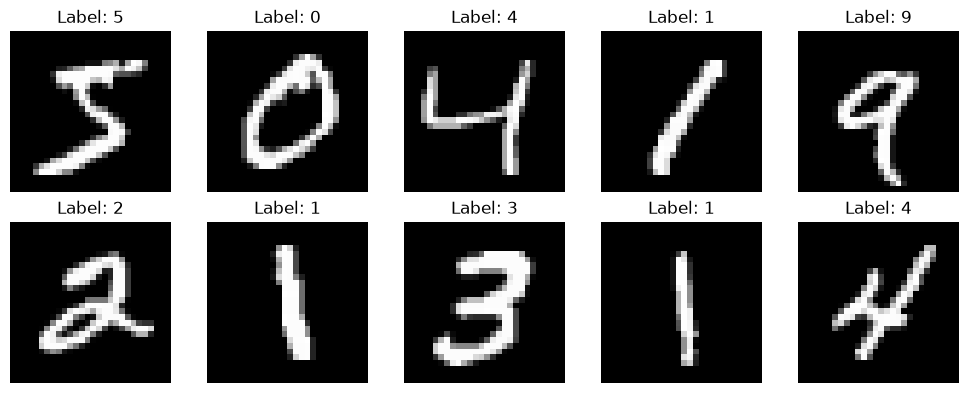

In [9]:
plt.figure(figsize=(10, 4))
for i in range(10):
    plt.subplot(2, 5, i+1)
    plt.imshow(x_train[i], cmap='gray')
    plt.title(f"Label: {y_train[i].argmax()}")
    plt.axis('off')
plt.tight_layout()
plt.show()

In [7]:
x_train[1]

array([[0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.    

---

#### 🔹 Step 4: Build the Neural Network Model

 - A Flatten layer reshapes a multi-dimensional input into a one-dimensional vector. It doesn't learn anything; it just restructures the data.

- A Dense layer is a fully-connected layer that performs learning. It uses weights and biases to learn patterns from the input it receives.

In [19]:
model = Sequential([
    Flatten(input_shape=(28, 28)),
    Dense(64, activation='relu'),
    Dense(64, activation='relu'),
    Dense(10, activation='softmax')
])

---

#### 🔹 Step 5: Compile the Model

 - categorical_crossentropy is a loss function used for multi-class classification that measures the difference between the true labels (which must be one-hot encoded) and the predicted probabilities from the model's softmax output.

In [20]:
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

---

#### 🔹 Step 6: Train the Model

In [ ]:
model.fit(x_train, y_train, epochs=5, validation_split=0.2)

Epoch 1/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9109 - loss: 0.3084 - val_accuracy: 0.9514 - val_loss: 0.1645
Epoch 2/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9582 - loss: 0.1370 - val_accuracy: 0.9617 - val_loss: 0.1300
Epoch 3/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9690 - loss: 0.0997 - val_accuracy: 0.9644 - val_loss: 0.1162
Epoch 4/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9753 - loss: 0.0774 - val_accuracy: 0.9721 - val_loss: 0.0980
Epoch 5/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9801 - loss: 0.0633 - val_accuracy: 0.9725 - val_loss: 0.0947


---

#### 🔹 Step 7: Evaluate Performance

In [12]:
loss, accuracy = model.evaluate(x_test, y_test)
print(f"Test Accuracy: {accuracy:.2f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9696 - loss: 0.0967
Test Accuracy: 0.97


In [22]:
model.save('mnist_model.h5')

---

## 🔍 Module 2: Visualizing Model Decisions


In [23]:
loaded_model = tf.keras.models.load_model('mnist_model.h5')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step


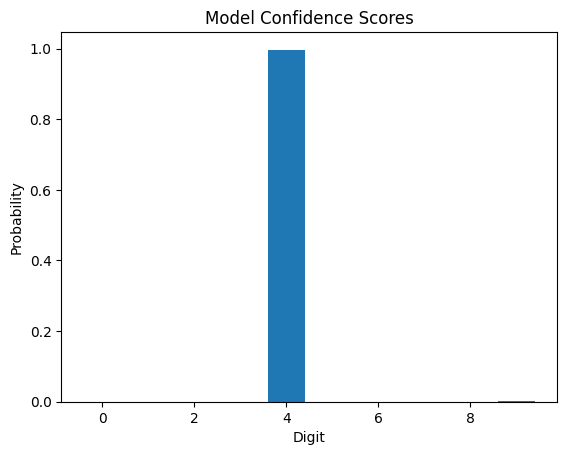

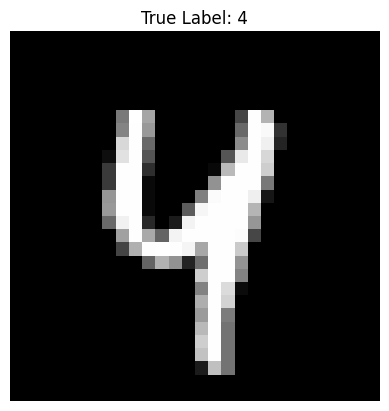

In [13]:
import numpy as np

# Select a test image
test_idx = 42
image = x_test[test_idx].reshape(1, 28, 28)
prediction = model.predict(image)[0]

# Display prediction scores
plt.bar(range(10), prediction)
plt.title("Model Confidence Scores")
plt.xlabel("Digit")
plt.ylabel("Probability")
plt.show()

# Display the actual image
plt.imshow(x_test[test_idx], cmap='gray')
plt.title(f"True Label: {y_test[test_idx].argmax()}")
plt.axis('off')
plt.show()

> 💬 **Takeaway:** This shows not only what the model predicted, but how confident it is about each digit.

---

### 🔹 Step 3: Visualize Misclassifications

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


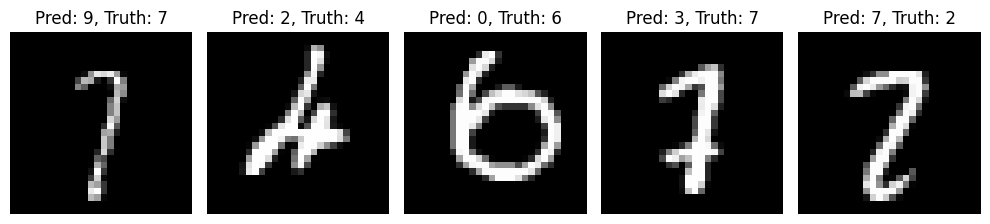

In [14]:
preds = model.predict(x_test)
pred_labels = preds.argmax(axis=1)
true_labels = y_test.argmax(axis=1)

# Find incorrect predictions
errors = np.where(pred_labels != true_labels)[0]

# Visualize a few
plt.figure(figsize=(10, 4))
for i in range(5):
    idx = errors[i]
    plt.subplot(1, 5, i+1)
    plt.imshow(x_test[idx], cmap='gray')
    plt.title(f"Pred: {pred_labels[idx]}, Truth: {true_labels[idx]}")
    plt.axis('off')
plt.tight_layout()
plt.show()